<a href="https://colab.research.google.com/github/Dhanush7-tech/Deep-Learning-LAB/blob/main/Lab-7/DeepLeaning_Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (10000, 784), Test shape: (2000, 784)


Model: "fc_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 16)             │       105,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 784)            │       105,904 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 - 6s - 71ms/step - loss: 0.3513 - val_loss: 0.2545
Epoch 2/20
79/79 - 0s - 4ms/step - loss: 0.2372 - val_loss: 0.2185
Epoch 3/20
79/79 - 0s - 4ms/step - loss: 0.2081 - val_loss: 0.1914
Epoch 4/20
79/79 - 1s - 8ms/step - loss: 0.1859 - val_loss: 0.1776
Epoch 5/20
79/79 - 0s - 4ms/step - loss: 0.1736 - val_loss: 0.1676
Epoch 6/20
79/79 - 1s - 8ms/step - loss: 0.1655 - val_loss: 0.1616
Epoch 7/20
79/79 - 0s - 4ms/step - loss: 0.1595 - val_loss: 0.1557
Epoch 8/20
79/79 - 1s - 7ms/step - loss: 0.1540 - val_loss: 0.1516
Epoch 9/20
79/79 - 1s - 7ms/step - loss: 0.1498 - val_loss: 0.1476
Epoch 10/20
79/79 - 1s - 8ms/step - loss: 0.1461 - val_loss: 0.1441
Epoch 11/20
79/79 - 1s - 9ms/step - loss: 0.1428 - val_loss: 0.1410
Epoch 12/20
79/79 - 1s - 6ms/step - loss: 0.1402 - val_loss: 0.1387
Epoch 13/20
79/79 - 0s - 6ms/step - loss: 0.1378 - val_loss: 0.1362
Epoch 14/20
79/79 - 1s - 7ms/step - loss: 0.1353 - val_loss: 0.1337
Epoch 15/20
79/79 - 1s - 6ms/step - loss: 0.1331 - val_l

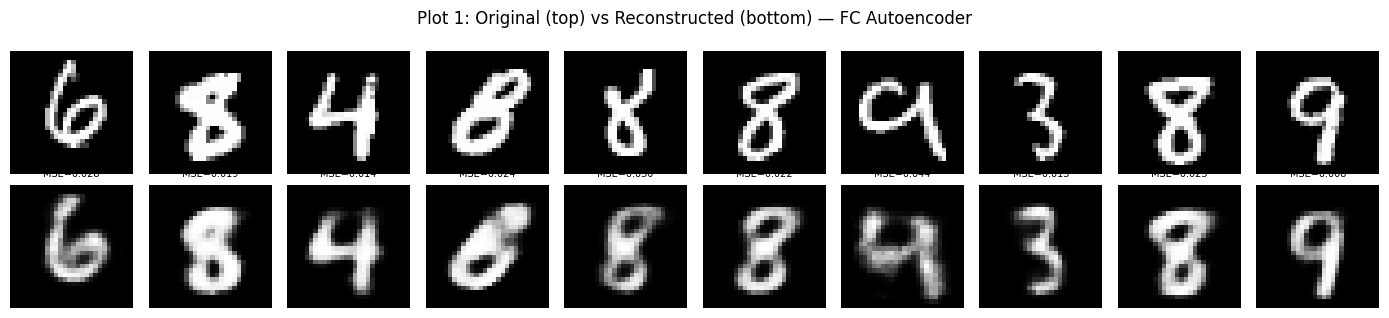

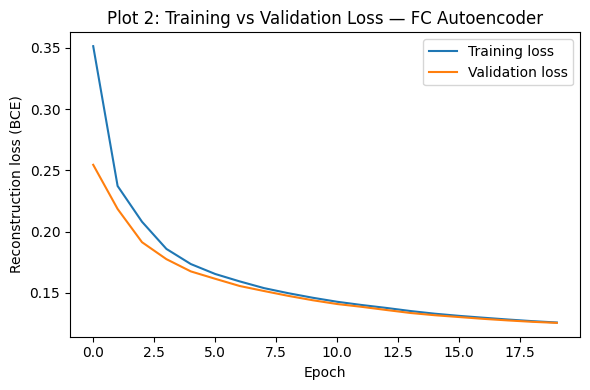


Mean test reconstruction MSE: 0.0209
Final training loss:   0.1259
Final validation loss: 0.1256


In [ ]:
"""
Fully Connected Autoencoder on MNIST
=====================================
Study 1 of 4: Basic FC Autoencoder

Pipeline: MNIST -> Normalize -> Encoder -> Latent (z) -> Decoder -> Reconstruction -> Evaluation

Architecture:
    Input 784 -> Dense 128 (ReLU) -> Dense 32 (ReLU) -> Latent 16
    -> Dense 32 (ReLU) -> Dense 128 (ReLU) -> Output 784 (Sigmoid)

Config:
    Latent dim   : 16
    Optimizer    : Adam
    Learning rate: 1e-3
    Batch size   : 128
    Epochs       : 20
    Loss         : Binary Cross-Entropy
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -----------------------------------------------------------------
# 1. Reproducibility
# -----------------------------------------------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------------------------------------------
# 2. Load MNIST and build the lab subset (10,000 train / 2,000 test)
# -----------------------------------------------------------------
(x_train_full, _), (x_test_full, _) = keras.datasets.mnist.load_data()

N_TRAIN = 10000
N_TEST = 2000

idx_train = np.random.choice(len(x_train_full), N_TRAIN, replace=False)
idx_test = np.random.choice(len(x_test_full), N_TEST, replace=False)

x_train = x_train_full[idx_train]
x_test = x_test_full[idx_test]

# -----------------------------------------------------------------
# 3. Preprocess: [0, 255] -> [0, 1], then flatten 28x28 -> 784
# -----------------------------------------------------------------
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_flat = x_train.reshape((-1, 784))
x_test_flat = x_test.reshape((-1, 784))

print(f"Train shape: {x_train_flat.shape}, Test shape: {x_test_flat.shape}")

# -----------------------------------------------------------------
# 4. Build the Fully Connected Autoencoder
# -----------------------------------------------------------------
LATENT_DIM = 16

# --- Encoder ---
encoder_input = keras.Input(shape=(784,), name="encoder_input")
x = layers.Dense(128, activation="relu")(encoder_input)
x = layers.Dense(32, activation="relu")(x)
latent = layers.Dense(LATENT_DIM, activation="relu", name="latent_vector")(x)
encoder = keras.Model(encoder_input, latent, name="encoder")

# --- Decoder ---
decoder_input = keras.Input(shape=(LATENT_DIM,), name="decoder_input")
x = layers.Dense(32, activation="relu")(decoder_input)
x = layers.Dense(128, activation="relu")(x)
decoder_output = layers.Dense(784, activation="sigmoid")(x)
decoder = keras.Model(decoder_input, decoder_output, name="decoder")

# --- Full Autoencoder (encoder + decoder) ---
autoencoder_input = keras.Input(shape=(784,))
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)
autoencoder = keras.Model(autoencoder_input, decoded, name="fc_autoencoder")

autoencoder.summary()

# -----------------------------------------------------------------
# 5. Compile and train
# -----------------------------------------------------------------
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
)

history = autoencoder.fit(
    x_train_flat, x_train_flat,
    validation_data=(x_test_flat, x_test_flat),
    epochs=20,
    batch_size=128,
    shuffle=True,
    verbose=2,
)

# -----------------------------------------------------------------
# 6. Reconstruct test images
# -----------------------------------------------------------------
reconstructions = autoencoder.predict(x_test_flat)
per_image_mse = np.mean(np.square(x_test_flat - reconstructions), axis=1)

# -----------------------------------------------------------------
# Plot 1: Original vs Reconstructed (10 test images)
# -----------------------------------------------------------------
N_SHOW = 10
show_idx = np.random.choice(len(x_test_flat), N_SHOW, replace=False)

fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 1.4, 3.2))
for i, idx in enumerate(show_idx):
    # Original
    axes[0, i].imshow(x_test_flat[idx].reshape(28, 28), cmap="gray")
    axes[0, i].axis("off")
    # Reconstruction
    axes[1, i].imshow(reconstructions[idx].reshape(28, 28), cmap="gray")
    axes[1, i].set_title(f"MSE={per_image_mse[idx]:.3f}", fontsize=7)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10)
fig.suptitle("Plot 1: Original (top) vs Reconstructed (bottom) — FC Autoencoder")
plt.tight_layout()
plt.savefig("plot1_original_vs_reconstructed_fc.png", dpi=150)
plt.show()

# -----------------------------------------------------------------
# Plot 2: Training vs Validation Reconstruction Loss
# -----------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss (BCE)")
plt.title("Plot 2: Training vs Validation Loss — FC Autoencoder")
plt.legend()
plt.tight_layout()
plt.savefig("plot2_loss_curve_fc.png", dpi=150)
plt.show()

# -----------------------------------------------------------------
# 7. Quantitative summary (for the write-up)
# -----------------------------------------------------------------
print(f"\nMean test reconstruction MSE: {per_image_mse.mean():.4f}")
print(f"Final training loss:   {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")

# -----------------------------------------------------------------
# Required written analysis (fill in after inspecting the plots)
# -----------------------------------------------------------------
# 1. Preservation of digit shape:
#    <comment on whether the overall stroke/shape of each digit survives>
#
# 2. Loss of fine details:
#    <comment on thin strokes, serifs, loop closures that get smoothed out>
#
# 3. Blurred regions:
#    <comment on where blur concentrates - edges, overlapping strokes>
#
# 4. Easy vs difficult samples:
#    <compare simple digits like 1/7 vs complex ones like 8/5>
#
# 5. Convergence / overfitting (from Plot 2):
#    <state whether train & val loss both plateau together (converged, no
#     overfitting) or val loss rises while train loss keeps falling
#     (overfitting)>

In [ ]:
# Install if needed
!pip install scikit-image -q

from skimage.metrics import structural_similarity as ssim
import numpy as np

# --- MSE (over the whole test set, flattened) ---
test_mse = np.mean(np.square(x_test_flat - reconstructions))

# --- MAE (over the whole test set, flattened) ---
test_mae = np.mean(np.abs(x_test_flat - reconstructions))

# --- SSIM (computed per image on the 28x28 image, then averaged) ---
originals_2d = x_test_flat.reshape(-1, 28, 28)
recon_2d = reconstructions.reshape(-1, 28, 28)

ssim_scores = [
    ssim(originals_2d[i], recon_2d[i], data_range=1.0)
    for i in range(len(originals_2d))
]
mean_ssim = np.mean(ssim_scores)

print("=" * 40)
print("Reconstruction Metrics (Test Set)")
print("=" * 40)
print(f"{'Metric':<12}{'Value':>10}")
print(f"{'Test MSE':<12}{test_mse:>10.4f}")
print(f"{'Test MAE':<12}{test_mae:>10.4f}")
print(f"{'Mean SSIM':<12}{mean_ssim:>10.4f}")

Reconstruction Metrics (Test Set)
Metric           Value
Test MSE        0.0209
Test MAE        0.0566
Mean SSIM       0.7607


Flat  -> train (10000, 784), test (2000, 784)
Image -> train (10000, 28, 28, 1), test (2000, 28, 28, 1)

Training Fully Connected Autoencoder...
Epoch 1/20
79/79 - 5s - 68ms/step - loss: 0.3394 - val_loss: 0.2504
Epoch 2/20
79/79 - 0s - 4ms/step - loss: 0.2279 - val_loss: 0.2072
Epoch 3/20
79/79 - 0s - 4ms/step - loss: 0.1955 - val_loss: 0.1836
Epoch 4/20
79/79 - 0s - 4ms/step - loss: 0.1801 - val_loss: 0.1734
Epoch 5/20
79/79 - 0s - 4ms/step - loss: 0.1711 - val_loss: 0.1657
Epoch 6/20
79/79 - 1s - 8ms/step - loss: 0.1632 - val_loss: 0.1581
Epoch 7/20
79/79 - 0s - 4ms/step - loss: 0.1561 - val_loss: 0.1521
Epoch 8/20
79/79 - 0s - 4ms/step - loss: 0.1509 - val_loss: 0.1483
Epoch 9/20
79/79 - 0s - 4ms/step - loss: 0.1475 - val_loss: 0.1455
Epoch 10/20
79/79 - 0s - 4ms/step - loss: 0.1449 - val_loss: 0.1434
Epoch 11/20
79/79 - 0s - 4ms/step - loss: 0.1425 - val_loss: 0.1415
Epoch 12/20
79/79 - 0s - 4ms/step - loss: 0.1402 - val_loss: 0.1395
Epoch 13/20
79/79 - 0s - 4ms/step - loss: 0.137

Model: "convolutional_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)


Training Convolutional Autoencoder...
Epoch 1/20
79/79 - 8s - 101ms/step - loss: 0.2137 - val_loss: 0.0986
Epoch 2/20
79/79 - 1s - 8ms/step - loss: 0.0908 - val_loss: 0.0853
Epoch 3/20
79/79 - 1s - 9ms/step - loss: 0.0824 - val_loss: 0.0810
Epoch 4/20
79/79 - 1s - 9ms/step - loss: 0.0787 - val_loss: 0.0775
Epoch 5/20
79/79 - 1s - 10ms/step - loss: 0.0766 - val_loss: 0.0753
Epoch 6/20
79/79 - 1s - 10ms/step - loss: 0.0751 - val_loss: 0.0739
Epoch 7/20
79/79 - 1s - 8ms/step - loss: 0.0739 - val_loss: 0.0736
Epoch 8/20
79/79 - 1s - 8ms/step - loss: 0.0731 - val_loss: 0.0720
Epoch 9/20
79/79 - 1s - 8ms/step - loss: 0.0722 - val_loss: 0.0717
Epoch 10/20
79/79 - 1s - 8ms/step - loss: 0.0716 - val_loss: 0.0715
Epoch 11/20
79/79 - 1s - 8ms/step - loss: 0.0711 - val_loss: 0.0711
Epoch 12/20
79/79 - 1s - 8ms/step - loss: 0.0706 - val_loss: 0.0707
Epoch 13/20
79/79 - 1s - 8ms/step - loss: 0.0702 - val_loss: 0.0703
Epoch 14/20
79/79 - 1s - 7ms/step - loss: 0.0698 - val_loss: 0.0699
Epoch 15/20
79

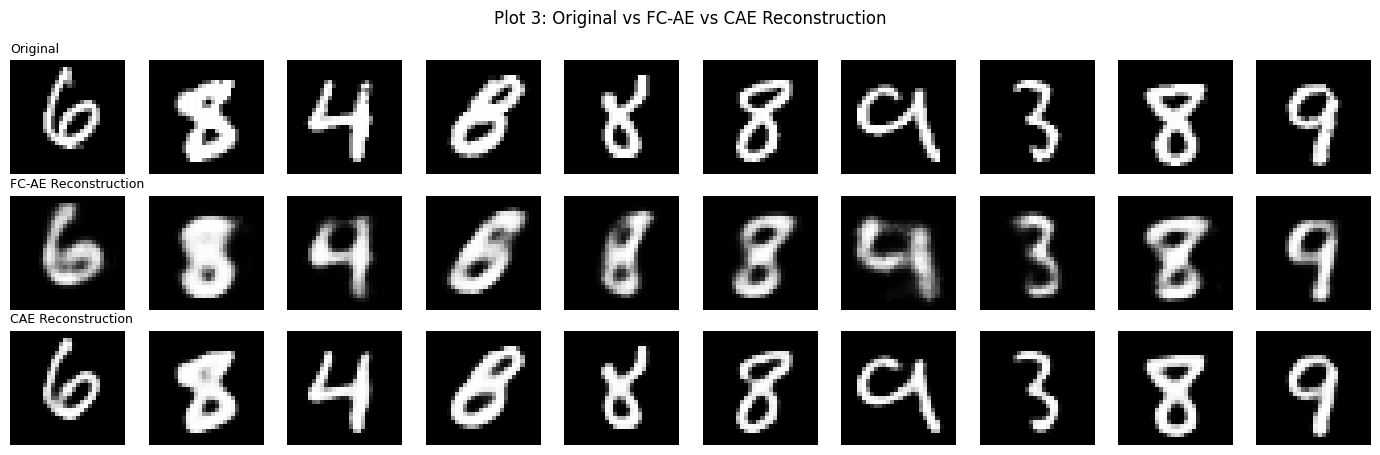

In [ ]:
"""
Convolutional Autoencoder + FC vs CNN Comparison
==================================================
Study 2: Convolutional Autoencoder (spatial structure preserved via Conv2D
          / MaxPooling2D in the encoder and UpSampling2D in the decoder)

Section 11: Compare the Fully Connected AE (Study 1) and this Convolutional AE
            on identical train/test data — MSE, MAE, SSIM, parameter count,
            and a visual reconstruction comparison (Plot 3).

Conceptual architecture:
    Input 28x28x1
    -> Conv2D(32,3,relu) -> MaxPooling2D(2)
    -> Conv2D(64,3,relu) -> MaxPooling2D(2)
    -> Conv2D(64,3,relu)                        [latent feature map]
    -> UpSampling2D(2) -> Conv2D(32,3,relu)
    -> UpSampling2D(2) -> Conv2D(1,3,sigmoid)   [output 28x28x1]
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from skimage.metrics import structural_similarity as ssim

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

EPOCHS = 20
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
LATENT_DIM = 16  # used only by the FC autoencoder

# =====================================================================
# 1. Load MNIST and build the SAME lab subset used for the FC autoencoder
#    (identical seed + sizes -> identical train/test split for a fair comparison)
# =====================================================================
(x_train_full, _), (x_test_full, _) = keras.datasets.mnist.load_data()

N_TRAIN, N_TEST = 10000, 2000
idx_train = np.random.choice(len(x_train_full), N_TRAIN, replace=False)
idx_test = np.random.choice(len(x_test_full), N_TEST, replace=False)

x_train = x_train_full[idx_train].astype("float32") / 255.0
x_test = x_test_full[idx_test].astype("float32") / 255.0

x_train_flat = x_train.reshape((-1, 784))
x_test_flat = x_test.reshape((-1, 784))

x_train_img = x_train[..., np.newaxis]   # (N, 28, 28, 1)
x_test_img = x_test[..., np.newaxis]

print(f"Flat  -> train {x_train_flat.shape}, test {x_test_flat.shape}")
print(f"Image -> train {x_train_img.shape}, test {x_test_img.shape}")


# =====================================================================
# 2. Fully Connected Autoencoder (Study 1 — rebuilt here for a fair,
#    same-split comparison against the CNN below)
# =====================================================================
fc_encoder_in = keras.Input(shape=(784,))
x = layers.Dense(128, activation="relu")(fc_encoder_in)
x = layers.Dense(32, activation="relu")(x)
fc_latent = layers.Dense(LATENT_DIM, activation="relu")(x)
fc_encoder = keras.Model(fc_encoder_in, fc_latent, name="fc_encoder")

fc_decoder_in = keras.Input(shape=(LATENT_DIM,))
x = layers.Dense(32, activation="relu")(fc_decoder_in)
x = layers.Dense(128, activation="relu")(x)
fc_decoder_out = layers.Dense(784, activation="sigmoid")(x)
fc_decoder = keras.Model(fc_decoder_in, fc_decoder_out, name="fc_decoder")

fc_ae_in = keras.Input(shape=(784,))
fc_ae = keras.Model(fc_ae_in, fc_decoder(fc_encoder(fc_ae_in)), name="fc_autoencoder")
fc_ae.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE), loss="binary_crossentropy")

print("\nTraining Fully Connected Autoencoder...")
fc_history = fc_ae.fit(
    x_train_flat, x_train_flat,
    validation_data=(x_test_flat, x_test_flat),
    epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True, verbose=2,
)

fc_recon_flat = fc_ae.predict(x_test_flat)
fc_recon_img = fc_recon_flat.reshape(-1, 28, 28, 1)


# =====================================================================
# 3. Convolutional Autoencoder — exact architecture from the spec
# =====================================================================
cae_input = keras.Input(shape=(28, 28, 1))

# --- Encoder ---
x = layers.Conv2D(32, 3, activation="relu", padding="same")(cae_input)
x = layers.MaxPooling2D(2, padding="same")(x)              # 14x14x32
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(2, padding="same")(x)               # 7x7x64
latent_feature_map = layers.Conv2D(64, 3, activation="relu", padding="same")(x)  # 7x7x64

# --- Decoder ---
x = layers.UpSampling2D(2)(latent_feature_map)               # 14x14x64
x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(2)(x)                                 # 28x28x32
cae_output = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)  # 28x28x1

cae = keras.Model(cae_input, cae_output, name="convolutional_autoencoder")
cae.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE), loss="binary_crossentropy")
cae.summary()

print("\nTraining Convolutional Autoencoder...")
cae_history = cae.fit(
    x_train_img, x_train_img,
    validation_data=(x_test_img, x_test_img),
    epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True, verbose=2,
)

cae_recon_img = cae.predict(x_test_img)


# =====================================================================
# 4. Metrics: MSE, MAE, SSIM, Parameter count — for both models
# =====================================================================
def compute_metrics(originals_img, recon_img):
    """originals_img, recon_img: (N, 28, 28, 1) in [0,1]."""
    o_flat = originals_img.reshape(len(originals_img), -1)
    r_flat = recon_img.reshape(len(recon_img), -1)

    mse = np.mean(np.square(o_flat - r_flat))
    mae = np.mean(np.abs(o_flat - r_flat))

    o_2d = originals_img.reshape(-1, 28, 28)
    r_2d = recon_img.reshape(-1, 28, 28)
    ssim_scores = [ssim(o_2d[i], r_2d[i], data_range=1.0) for i in range(len(o_2d))]
    mean_ssim = np.mean(ssim_scores)

    return mse, mae, mean_ssim


fc_mse, fc_mae, fc_ssim = compute_metrics(x_test_img, fc_recon_img)
cae_mse, cae_mae, cae_ssim = compute_metrics(x_test_img, cae_recon_img)

fc_params = fc_ae.count_params()
cae_params = cae.count_params()

print("\n" + "=" * 70)
print("Comparison: Fully Connected AE vs Convolutional AE")
print("=" * 70)
print(f"{'Model':<22}{'MSE':>10}{'MAE':>10}{'SSIM':>10}{'Parameters':>14}")
print(f"{'Fully Connected AE':<22}{fc_mse:>10.4f}{fc_mae:>10.4f}{fc_ssim:>10.4f}{fc_params:>14,}")
print(f"{'Convolutional AE':<22}{cae_mse:>10.4f}{cae_mae:>10.4f}{cae_ssim:>10.4f}{cae_params:>14,}")


# =====================================================================
# Plot 3: Original -> FC-AE Reconstruction -> CAE Reconstruction
# =====================================================================
N_SHOW = 10
show_idx = np.random.choice(len(x_test_img), N_SHOW, replace=False)

fig, axes = plt.subplots(3, N_SHOW, figsize=(N_SHOW * 1.4, 4.6))
for i, j in enumerate(show_idx):
    axes[0, i].imshow(np.squeeze(x_test_img[j]), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(np.squeeze(fc_recon_img[j]), cmap="gray")
    axes[1, i].axis("off")
    axes[2, i].imshow(np.squeeze(cae_recon_img[j]), cmap="gray")
    axes[2, i].axis("off")

axes[0, 0].set_title("Original", fontsize=9, loc="left")
axes[1, 0].set_title("FC-AE Reconstruction", fontsize=9, loc="left")
axes[2, 0].set_title("CAE Reconstruction", fontsize=9, loc="left")
fig.suptitle("Plot 3: Original vs FC-AE vs CAE Reconstruction")
plt.tight_layout()
plt.savefig("plot3_fc_vs_cae_reconstructions.png", dpi=150)
plt.show()

# -----------------------------------------------------------------
# Required inference (fill in after inspecting the metrics + Plot 3)
# -----------------------------------------------------------------
# How does preserving spatial locality through convolution affect
# reconstruction?
#   - Compare MSE/MAE/SSIM: does the CAE reconstruct more accurately
#     despite having a similar or different parameter budget?
#   - Look at Plot 3: are edges, loop closures, and stroke width sharper
#     in the CAE reconstructions than the FC-AE ones?
#   - Convolution + pooling preserve local spatial relationships (a pixel's
#     neighborhood matters), whereas the FC autoencoder flattens the image
#     and treats every pixel as independent from the start, discarding
#     2D adjacency information before the network ever sees it. Discuss
#     how this explains any sharper/more structurally faithful CAE output.
#   - Note any trade-offs observed (e.g. training time, parameter count).

Image -> train (10000, 28, 28, 1), test (2000, 28, 28, 1)
Generating mixed-noise training set (Gaussian + Salt-and-Pepper)...


Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)


Training Denoising Autoencoder...
Epoch 1/20
79/79 - 8s - 97ms/step - loss: 0.3041 - val_loss: 0.1335
Epoch 2/20
79/79 - 1s - 9ms/step - loss: 0.1145 - val_loss: 0.1015
Epoch 3/20
79/79 - 1s - 15ms/step - loss: 0.0979 - val_loss: 0.0931
Epoch 4/20
79/79 - 1s - 8ms/step - loss: 0.0925 - val_loss: 0.0896
Epoch 5/20
79/79 - 1s - 8ms/step - loss: 0.0895 - val_loss: 0.0874
Epoch 6/20
79/79 - 1s - 8ms/step - loss: 0.0874 - val_loss: 0.0857
Epoch 7/20
79/79 - 1s - 8ms/step - loss: 0.0858 - val_loss: 0.0842
Epoch 8/20
79/79 - 1s - 8ms/step - loss: 0.0846 - val_loss: 0.0834
Epoch 9/20
79/79 - 1s - 8ms/step - loss: 0.0835 - val_loss: 0.0825
Epoch 10/20
79/79 - 1s - 9ms/step - loss: 0.0828 - val_loss: 0.0819
Epoch 11/20
79/79 - 1s - 9ms/step - loss: 0.0821 - val_loss: 0.0814
Epoch 12/20
79/79 - 1s - 9ms/step - loss: 0.0815 - val_loss: 0.0810
Epoch 13/20
79/79 - 1s - 8ms/step - loss: 0.0810 - val_loss: 0.0806
Epoch 14/20
79/79 - 1s - 8ms/step - loss: 0.0806 - val_loss: 0.0802
Epoch 15/20
79/79 - 

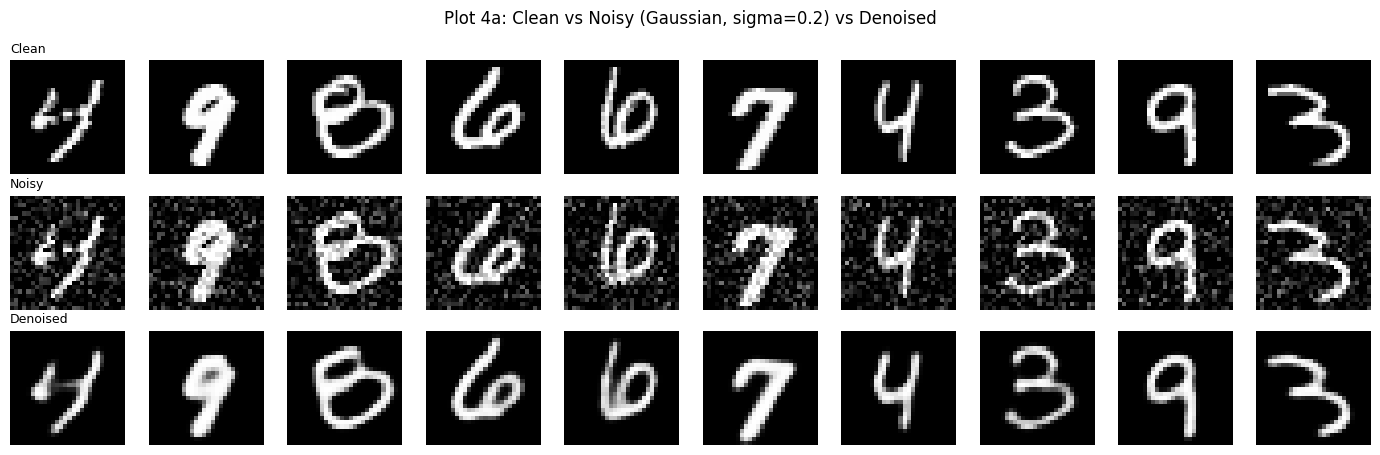

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


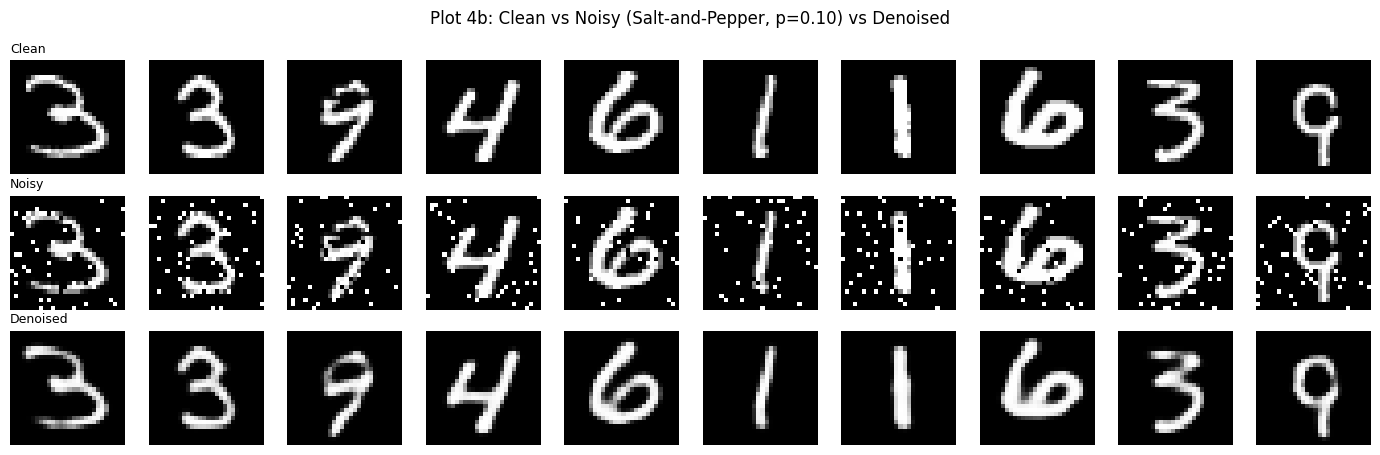


Plot 5 Report: Noise Level (Gaussian sigma) vs Reconstruction Quality
Noise Level          MSE       MAE      SSIM
0.1               0.0037    0.0189    0.9583
0.2               0.0048    0.0222    0.9445
0.3               0.0069    0.0277    0.9167

Additional Report: Noise Level (Salt-and-Pepper p) vs Reconstruction Quality
Noise Level          MSE       MAE      SSIM
0.05              0.0043    0.0199    0.9520
0.1               0.0055    0.0227    0.9379
0.2               0.0087    0.0300    0.8932


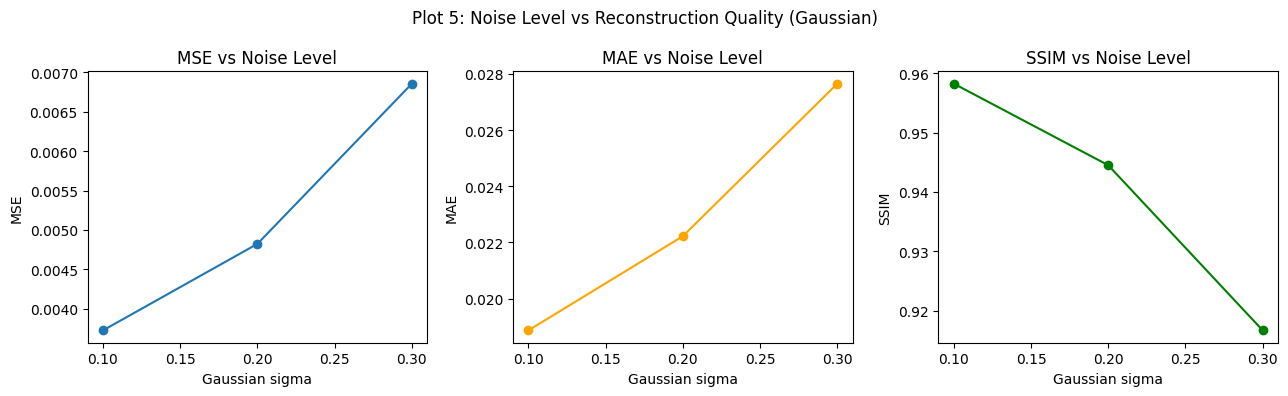

In [ ]:
"""
Denoising Convolutional Autoencoder on MNIST
==============================================
Study 3: Denoising Autoencoder

Training mapping:  x~ (noisy) -> Encoder -> z -> Decoder -> x_hat (denoised)
Target is always the CLEAN image x, even though the input is corrupted.

Corruption types used (>= 2, as required):
    1. Gaussian noise:        x~ = clip(x + n),  n ~ N(0, sigma^2),  sigma in {0.1, 0.2, 0.3}
    2. Salt-and-pepper noise: randomly replace a proportion p of pixels with 0 or 1,
                               p in {0.05, 0.10, 0.20}

The model is trained on a MIX of both corruption types (random type + random level
per training image) so it learns to denoise robustly rather than overfitting to one
specific noise level, then evaluated separately at each noise level for Plot 5 / the
report table.
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from skimage.metrics import structural_similarity as ssim

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

EPOCHS = 20
BATCH_SIZE = 128
LEARNING_RATE = 1e-3

GAUSSIAN_SIGMAS = [0.1, 0.2, 0.3]
SP_PROBS = [0.05, 0.10, 0.20]

# =====================================================================
# 1. Load MNIST and build the same lab subset (10,000 train / 2,000 test)
# =====================================================================
(x_train_full, _), (x_test_full, _) = keras.datasets.mnist.load_data()

N_TRAIN, N_TEST = 10000, 2000
idx_train = np.random.choice(len(x_train_full), N_TRAIN, replace=False)
idx_test = np.random.choice(len(x_test_full), N_TEST, replace=False)

x_train = x_train_full[idx_train].astype("float32") / 255.0
x_test = x_test_full[idx_test].astype("float32") / 255.0

x_train_img = x_train[..., np.newaxis]   # (N, 28, 28, 1)
x_test_img = x_test[..., np.newaxis]

print(f"Image -> train {x_train_img.shape}, test {x_test_img.shape}")


# =====================================================================
# 2. Noise functions
# =====================================================================
def add_gaussian_noise(images, sigma):
    """x~ = clip(x + n), n ~ N(0, sigma^2)."""
    noisy = images + np.random.normal(loc=0.0, scale=sigma, size=images.shape)
    return np.clip(noisy, 0.0, 1.0).astype("float32")


def add_salt_pepper_noise(images, p):
    """Randomly replace a proportion p of pixels with 0 (pepper) or 1 (salt)."""
    noisy = images.copy()
    mask = np.random.random(images.shape) < p
    salt_mask = mask & (np.random.random(images.shape) < 0.5)
    pepper_mask = mask & ~salt_mask
    noisy[salt_mask] = 1.0
    noisy[pepper_mask] = 0.0
    return noisy.astype("float32")


def make_mixed_noisy_training_set(images):
    """
    For each image, randomly pick ONE of the two corruption types and a
    random level from the suggested ranges, so the model sees a variety
    of noise types/levels during training.
    """
    noisy = np.empty_like(images)
    for i in range(len(images)):
        img = images[i:i + 1]
        if np.random.random() < 0.5:
            sigma = np.random.choice(GAUSSIAN_SIGMAS)
            noisy[i] = add_gaussian_noise(img, sigma)[0]
        else:
            p = np.random.choice(SP_PROBS)
            noisy[i] = add_salt_pepper_noise(img, p)[0]
    return noisy


print("Generating mixed-noise training set (Gaussian + Salt-and-Pepper)...")
x_train_noisy = make_mixed_noisy_training_set(x_train_img)


# =====================================================================
# 3. Denoising Convolutional Autoencoder (same conv architecture as the
#    plain CAE — Conv/Pool encoder, UpSampling decoder)
# =====================================================================
dae_input = keras.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, 3, activation="relu", padding="same")(dae_input)
x = layers.MaxPooling2D(2, padding="same")(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(2, padding="same")(x)
latent_feature_map = layers.Conv2D(64, 3, activation="relu", padding="same")(x)

x = layers.UpSampling2D(2)(latent_feature_map)
x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(2)(x)
dae_output = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

dae = keras.Model(dae_input, dae_output, name="denoising_autoencoder")
dae.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE), loss="binary_crossentropy")
dae.summary()

# For validation during training, corrupt the test set the same mixed way
x_test_noisy_for_val = make_mixed_noisy_training_set(x_test_img)

print("\nTraining Denoising Autoencoder...")
history = dae.fit(
    x_train_noisy, x_train_img,                              # noisy -> clean
    validation_data=(x_test_noisy_for_val, x_test_img),
    epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True, verbose=2,
)


# =====================================================================
# 4. Metrics helper
# =====================================================================
def compute_metrics(originals_img, recon_img):
    o_flat = originals_img.reshape(len(originals_img), -1)
    r_flat = recon_img.reshape(len(recon_img), -1)
    mse = np.mean(np.square(o_flat - r_flat))
    mae = np.mean(np.abs(o_flat - r_flat))
    o_2d = originals_img.reshape(-1, 28, 28)
    r_2d = recon_img.reshape(-1, 28, 28)
    scores = [ssim(o_2d[i], r_2d[i], data_range=1.0) for i in range(len(o_2d))]
    return mse, mae, np.mean(scores)


# =====================================================================
# Plot 4: Clean vs Noisy vs Denoised (>= 10 images)
#   Shown separately for Gaussian and Salt-and-Pepper corruption.
# =====================================================================
def plot4_clean_noisy_denoised(clean_img, noisy_img, denoised_img, title, fname, n=10):
    idx = np.random.choice(len(clean_img), n, replace=False)
    fig, axes = plt.subplots(3, n, figsize=(n * 1.4, 4.6))
    for i, j in enumerate(idx):
        axes[0, i].imshow(np.squeeze(clean_img[j]), cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(np.squeeze(noisy_img[j]), cmap="gray"); axes[1, i].axis("off")
        axes[2, i].imshow(np.squeeze(denoised_img[j]), cmap="gray"); axes[2, i].axis("off")
    axes[0, 0].set_title("Clean", fontsize=9, loc="left")
    axes[1, 0].set_title("Noisy", fontsize=9, loc="left")
    axes[2, 0].set_title("Denoised", fontsize=9, loc="left")
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.show()


# Gaussian example at sigma = 0.2
x_test_gauss02 = add_gaussian_noise(x_test_img, sigma=0.2)
denoised_gauss02 = dae.predict(x_test_gauss02)
plot4_clean_noisy_denoised(
    x_test_img, x_test_gauss02, denoised_gauss02,
    "Plot 4a: Clean vs Noisy (Gaussian, sigma=0.2) vs Denoised",
    "plot4a_denoising_gaussian.png",
)

# Salt-and-pepper example at p = 0.10
x_test_sp10 = add_salt_pepper_noise(x_test_img, p=0.10)
denoised_sp10 = dae.predict(x_test_sp10)
plot4_clean_noisy_denoised(
    x_test_img, x_test_sp10, denoised_sp10,
    "Plot 4b: Clean vs Noisy (Salt-and-Pepper, p=0.10) vs Denoised",
    "plot4b_denoising_saltpepper.png",
)


# =====================================================================
# Plot 5 + Report Table: Noise Level vs Reconstruction Quality (Gaussian)
# =====================================================================
gaussian_results = []
for sigma in GAUSSIAN_SIGMAS:
    x_noisy = add_gaussian_noise(x_test_img, sigma)
    x_denoised = dae.predict(x_noisy, verbose=0)
    mse, mae, mean_ssim = compute_metrics(x_test_img, x_denoised)
    gaussian_results.append((sigma, mse, mae, mean_ssim))

print("\n" + "=" * 60)
print("Plot 5 Report: Noise Level (Gaussian sigma) vs Reconstruction Quality")
print("=" * 60)
print(f"{'Noise Level':<14}{'MSE':>10}{'MAE':>10}{'SSIM':>10}")
for sigma, mse, mae, mean_ssim in gaussian_results:
    print(f"{sigma:<14}{mse:>10.4f}{mae:>10.4f}{mean_ssim:>10.4f}")

# Also report for salt-and-pepper, since >=2 corruption types were required
sp_results = []
for p in SP_PROBS:
    x_noisy = add_salt_pepper_noise(x_test_img, p)
    x_denoised = dae.predict(x_noisy, verbose=0)
    mse, mae, mean_ssim = compute_metrics(x_test_img, x_denoised)
    sp_results.append((p, mse, mae, mean_ssim))

print("\n" + "=" * 60)
print("Additional Report: Noise Level (Salt-and-Pepper p) vs Reconstruction Quality")
print("=" * 60)
print(f"{'Noise Level':<14}{'MSE':>10}{'MAE':>10}{'SSIM':>10}")
for p, mse, mae, mean_ssim in sp_results:
    print(f"{p:<14}{mse:>10.4f}{mae:>10.4f}{mean_ssim:>10.4f}")

# --- Plot 5: line plots of MSE / MAE / SSIM vs noise level ---
sigmas = [r[0] for r in gaussian_results]
mses = [r[1] for r in gaussian_results]
maes = [r[2] for r in gaussian_results]
ssims = [r[3] for r in gaussian_results]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(sigmas, mses, marker="o"); axes[0].set_title("MSE vs Noise Level")
axes[0].set_xlabel("Gaussian sigma"); axes[0].set_ylabel("MSE")
axes[1].plot(sigmas, maes, marker="o", color="orange"); axes[1].set_title("MAE vs Noise Level")
axes[1].set_xlabel("Gaussian sigma"); axes[1].set_ylabel("MAE")
axes[2].plot(sigmas, ssims, marker="o", color="green"); axes[2].set_title("SSIM vs Noise Level")
axes[2].set_xlabel("Gaussian sigma"); axes[2].set_ylabel("SSIM")
fig.suptitle("Plot 5: Noise Level vs Reconstruction Quality (Gaussian)")
plt.tight_layout()
plt.savefig("plot5_noise_level_vs_quality.png", dpi=150)
plt.show()

# -----------------------------------------------------------------
# Required inference (fill in after inspecting the table + Plot 5)
# -----------------------------------------------------------------
# - How does increasing corruption (sigma 0.1 -> 0.2 -> 0.3, or p 0.05 -> 0.20)
#   affect MSE / MAE / SSIM? Does quality degrade linearly, or does it fall
#   off sharply past a certain noise level?
# - Does the denoised output still recover the MAJOR STRUCTURE of the digit
#   (overall shape/topology) even at the highest noise level, or does the
#   model start losing the digit's identity (e.g. confusing an 8 for a 0)?
# - Compare robustness to Gaussian noise vs salt-and-pepper noise at
#   comparable severity — is one corruption type harder to reverse than
#   the other, and why (e.g. salt-and-pepper is sparse but extreme per-pixel,
#   Gaussian is dense but bounded)?

Image -> train (10000, 28, 28, 1), test (2000, 28, 28, 1)


Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ conv2d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │    100,384 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         66 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         66 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_1          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 119,332 (466.14 KB)

 Trainable params: 119,332 (466.14 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)


Training VAE...
Epoch 1/20
79/79 - 12s - 152ms/step - kl_loss: 0.4882 - loss: 317.9735 - recon_loss: 317.4852 - val_kl_loss: 1.1828 - val_loss: 215.8886 - val_recon_loss: 214.7059
Epoch 2/20
79/79 - 1s - 8ms/step - kl_loss: 1.2477 - loss: 210.3230 - recon_loss: 209.0753 - val_kl_loss: 2.3984 - val_loss: 204.3913 - val_recon_loss: 201.9928
Epoch 3/20
79/79 - 1s - 9ms/step - kl_loss: 2.8753 - loss: 201.5527 - recon_loss: 198.6774 - val_kl_loss: 2.7052 - val_loss: 199.8728 - val_recon_loss: 197.1675
Epoch 4/20
79/79 - 1s - 9ms/step - kl_loss: 3.0991 - loss: 198.7184 - recon_loss: 195.6193 - val_kl_loss: 3.1759 - val_loss: 196.9822 - val_recon_loss: 193.8063
Epoch 5/20
79/79 - 1s - 9ms/step - kl_loss: 3.2667 - loss: 196.0835 - recon_loss: 192.8168 - val_kl_loss: 3.3110 - val_loss: 194.6094 - val_recon_loss: 191.2984
Epoch 6/20
79/79 - 1s - 15ms/step - kl_loss: 3.6285 - loss: 193.4593 - recon_loss: 189.8308 - val_kl_loss: 4.6252 - val_loss: 189.2426 - val_recon_loss: 184.6174
Epoch 7/20
79

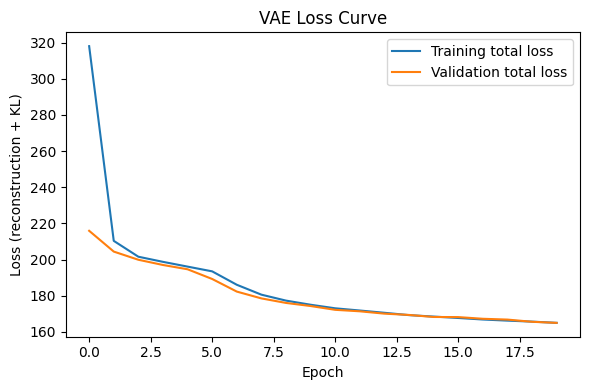


Final train loss: 164.99 (recon: 158.75, kl: 6.25)
Final val loss:   164.97 (recon: 158.71, kl: 6.25)
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


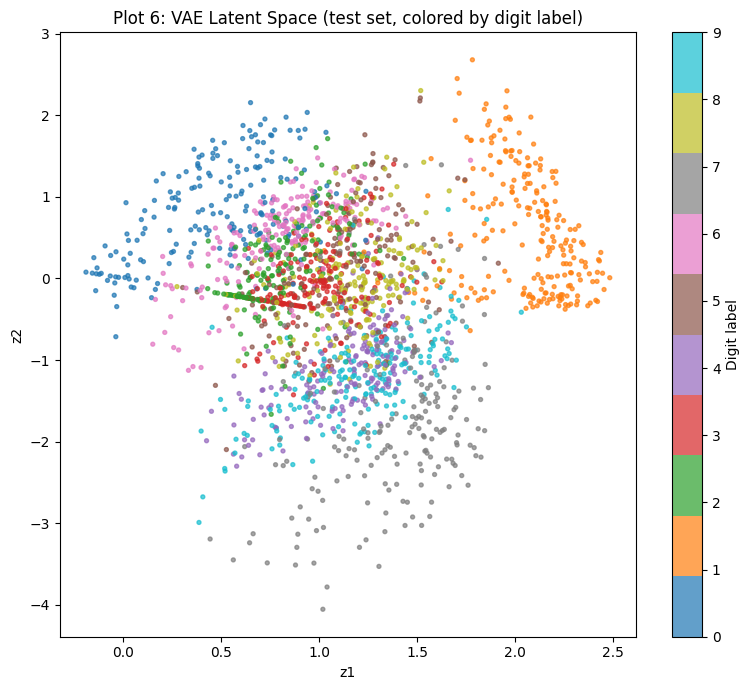

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step


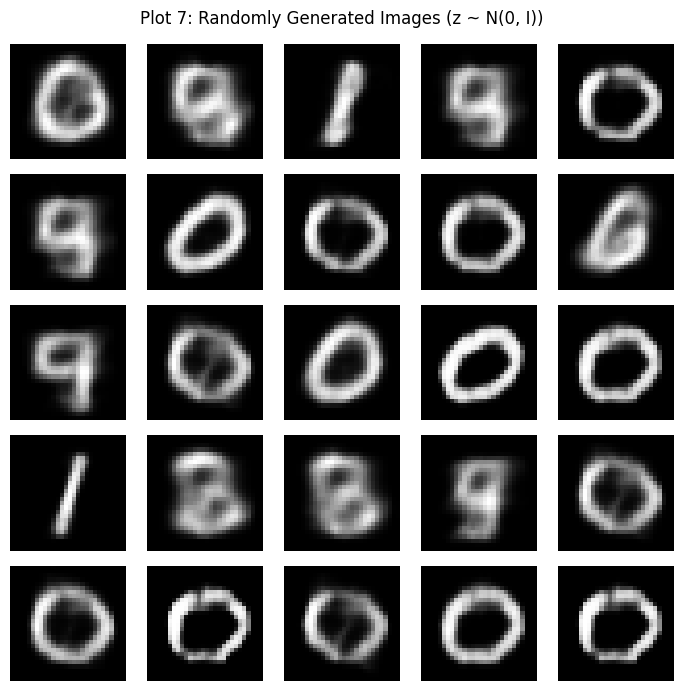

In [ ]:
"""
Variational Autoencoder (VAE) on MNIST — Study 4
====================================================
Encoder:  x -> Conv layers -> Flatten -> Dense -> (mu, log_var) in R^2
Sampling: z = mu + sigma * epsilon,  epsilon ~ N(0, I)   [reparameterization trick]
Decoder:  z -> Dense -> Reshape -> Conv2DTranspose layers -> 28x28x1

Loss:  L_VAE = L_rec (binary cross-entropy) + L_KL (KL divergence to N(0, I))

Latent dimension is kept at 2 so it can be visualized directly (Plot 6).
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

EPOCHS = 20
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
LATENT_DIM = 2  # small, so the latent space can be visualized in 2D

# =====================================================================
# 1. Load MNIST + labels (labels used ONLY for visualizing Plot 6,
#    never supplied to the VAE during training) — same lab subset
# =====================================================================
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

N_TRAIN, N_TEST = 10000, 2000
idx_train = np.random.choice(len(x_train_full), N_TRAIN, replace=False)
idx_test = np.random.choice(len(x_test_full), N_TEST, replace=False)

x_train = x_train_full[idx_train].astype("float32") / 255.0
x_test = x_test_full[idx_test].astype("float32") / 255.0
y_train = y_train_full[idx_train]     # NOT used in training, only for Plot 6
y_test = y_test_full[idx_test]        # NOT used in training, only for Plot 6

x_train_img = x_train[..., np.newaxis]   # (N, 28, 28, 1)
x_test_img = x_test[..., np.newaxis]

print(f"Image -> train {x_train_img.shape}, test {x_test_img.shape}")


# =====================================================================
# 2. Sampling layer: reparameterization trick
#    z = mu + sigma * epsilon,  epsilon ~ N(0, I)
# =====================================================================
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


# =====================================================================
# 3. Encoder: Conv layers -> Flatten -> Dense -> (mu, log_var)
# =====================================================================
encoder_input = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_input)  # 14x14x32
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)              # 7x7x64
shape_before_flatten = x.shape[1:]  # (7, 7, 64) — needed to invert Flatten in the decoder
x = layers.Flatten()(x)
x = layers.Dense(32, activation="relu")(x)

z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_input, [z_mean, z_log_var, z], name="vae_encoder")
encoder.summary()

# =====================================================================
# 4. Decoder: z -> Dense -> Reshape -> Conv2DTranspose layers -> 28x28x1
# =====================================================================
decoder_input = keras.Input(shape=(LATENT_DIM,))
x = layers.Dense(int(np.prod(shape_before_flatten)), activation="relu")(decoder_input)
x = layers.Reshape(shape_before_flatten)(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)     # 14x14x64
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)     # 28x28x32
decoder_output = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)          # 28x28x1

decoder = keras.Model(decoder_input, decoder_output, name="vae_decoder")
decoder.summary()


# =====================================================================
# 5. VAE model: custom train_step / test_step implementing
#    L_VAE = L_rec (BCE) + L_KL
# =====================================================================
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def _compute_losses(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)
        # Reconstruction loss: BCE summed over pixels, averaged over batch
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(
                keras.losses.binary_crossentropy(x, reconstruction), axis=(1, 2)
            )
        )
        # KL divergence: -1/2 * sum_j(1 + log_var - mu^2 - var), averaged over batch
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(x)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        total_loss, recon_loss, kl_loss = self._compute_losses(x)
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}


vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE))

print("\nTraining VAE...")
history = vae.fit(
    x_train_img,
    validation_data=(x_test_img,),
    epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True, verbose=2,
)

# -----------------------------------------------------------------
# Loss curve (total / reconstruction / KL)
# -----------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Training total loss")
plt.plot(history.history["val_loss"], label="Validation total loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (reconstruction + KL)")
plt.title("VAE Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig("vae_loss_curve.png", dpi=150)
plt.show()

print(f"\nFinal train loss: {history.history['loss'][-1]:.2f} "
      f"(recon: {history.history['recon_loss'][-1]:.2f}, kl: {history.history['kl_loss'][-1]:.2f})")
print(f"Final val loss:   {history.history['val_loss'][-1]:.2f} "
      f"(recon: {history.history['val_recon_loss'][-1]:.2f}, kl: {history.history['val_kl_loss'][-1]:.2f})")


# =====================================================================
# Plot 6: VAE Latent Space — encode test images, color by digit label
#   (labels are used ONLY here, for visualization — not during training)
# =====================================================================
z_mean_test, _, _ = encoder.predict(x_test_img)

plt.figure(figsize=(8, 7))
scatter = plt.scatter(
    z_mean_test[:, 0], z_mean_test[:, 1],
    c=y_test, cmap="tab10", s=8, alpha=0.7
)
plt.colorbar(scatter, ticks=range(10), label="Digit label")
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Plot 6: VAE Latent Space (test set, colored by digit label)")
plt.tight_layout()
plt.savefig("plot6_vae_latent_space.png", dpi=150)
plt.show()


# =====================================================================
# Plot 7: Randomly Generated Images — sample z ~ N(0, I), decode
# =====================================================================
N_GEN = 25  # >= 25 as required
grid_size = int(np.sqrt(N_GEN))  # 5x5 grid

random_latents = np.random.normal(size=(N_GEN, LATENT_DIM)).astype("float32")
generated_images = decoder.predict(random_latents)

fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size * 1.4, grid_size * 1.4))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.squeeze(generated_images[i]), cmap="gray")
    ax.axis("off")
fig.suptitle("Plot 7: Randomly Generated Images (z ~ N(0, I))")
plt.tight_layout()
plt.savefig("plot7_vae_generated_samples.png", dpi=150)
plt.show()

# -----------------------------------------------------------------
# Required inference — Plot 6 (Latent Space)
# -----------------------------------------------------------------
# - Do samples belonging to the SAME digit cluster together in similar
#   regions of the z1-z2 plane, or are they scattered widely?
# - Which digit pairs OVERLAP in the latent space (e.g. 4/9, 3/8, 5/6 are
#   commonly confused visually — check if this shows up as overlapping
#   colored regions)? Overlap suggests the VAE finds those digits visually
#   / structurally similar in a way that's hard to separate with only 2
#   latent dimensions.
# - Note whether clusters are compact and well-separated (indicates a
#   well-organized, smooth latent space) or diffuse/overlapping (indicates
#   the 2D bottleneck is too small to cleanly separate all 10 classes).
#
# Required inference — Plot 7 (Generated Images)
# -----------------------------------------------------------------
# - Do the generated samples resemble real handwritten digits overall?
# - Are individual digit shapes recognizable, or blurry/ambiguous?
# - Is there visible variation across the 25 samples (different digits,
#   different writing styles), reflecting the diversity the prior N(0,I)
#   should produce given the class overlap seen in Plot 6?
# - Are any samples ambiguous or unrealistic (e.g. blend of two digits,
#   or a shape that doesn't resemble any digit)? Relate this back to
#   regions of the latent space (Plot 6) where classes overlapped or
#   were sparsely sampled during training.

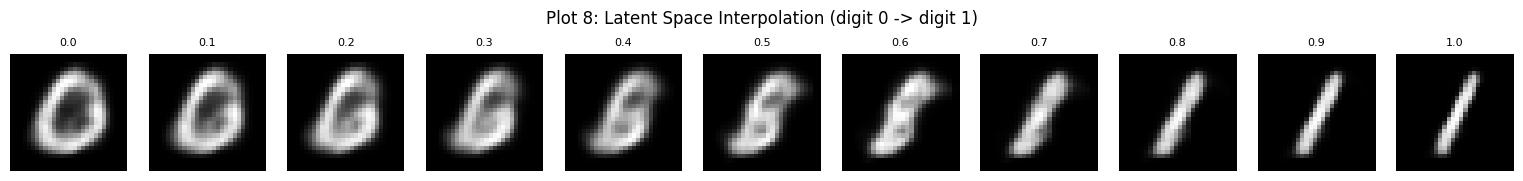

In [ ]:
# =====================================================================
# 20. Latent Space Interpolation
#   Pick two latent vectors zA, zB (here: the encoded means of two test
#   images of DIFFERENT digits), construct
#   z(alpha) = (1-alpha)*zA + alpha*zB for alpha = 0, 0.1, ..., 1,
#   and decode every interpolated vector.
# =====================================================================

# Pick one test image for digit A and one for digit B (edit these labels
# to interpolate between any two digit classes you want to inspect)
DIGIT_A, DIGIT_B = 0, 1

idx_A = np.where(y_test == DIGIT_A)[0][0]
idx_B = np.where(y_test == DIGIT_B)[0][0]

zA, _, _ = encoder.predict(x_test_img[idx_A:idx_A + 1], verbose=0)
zB, _, _ = encoder.predict(x_test_img[idx_B:idx_B + 1], verbose=0)
zA, zB = zA[0], zB[0]  # (LATENT_DIM,) each

alphas = np.arange(0.0, 1.01, 0.1)  # 0, 0.1, 0.2, ..., 1.0  -> 11 steps
interpolated_z = np.array([(1 - a) * zA + a * zB for a in alphas], dtype="float32")

decoded_sequence = decoder.predict(interpolated_z, verbose=0)

fig, axes = plt.subplots(1, len(alphas), figsize=(len(alphas) * 1.4, 1.8))
for i, ax in enumerate(axes):
    ax.imshow(np.squeeze(decoded_sequence[i]), cmap="gray")
    ax.set_title(f"{alphas[i]:.1f}", fontsize=8)
    ax.axis("off")
fig.suptitle(f"Plot 8: Latent Space Interpolation (digit {DIGIT_A} -> digit {DIGIT_B})")
plt.tight_layout()
plt.savefig("plot8_latent_interpolation.png", dpi=150)
plt.show()

In [ ]:
import numpy as np
from skimage.metrics import structural_similarity as ssim

def compute_metrics(originals_img, recon_img):
    o_flat = originals_img.reshape(len(originals_img), -1)
    r_flat = recon_img.reshape(len(recon_img), -1)
    mse = np.mean(np.square(o_flat - r_flat))
    mae = np.mean(np.abs(o_flat - r_flat))
    o_2d = originals_img.reshape(-1, 28, 28)
    r_2d = recon_img.reshape(-1, 28, 28)
    scores = [ssim(o_2d[i], r_2d[i], data_range=1.0) for i in range(len(o_2d))]
    return mse, mae, np.mean(scores)

# --- FC AE (needs the flattened test set) ---
fc_recon = fc_ae.predict(x_test_flat, verbose=0).reshape(-1, 28, 28, 1)
fc_mse, fc_mae, fc_ssim_val = compute_metrics(x_test_img, fc_recon)

# --- Convolutional AE ---
cae_recon = cae.predict(x_test_img, verbose=0)
cae_mse, cae_mae, cae_ssim_val = compute_metrics(x_test_img, cae_recon)

# --- Denoising CAE (evaluated on CLEAN input, for a fair MSE/MAE/SSIM comparison) ---
dae_recon = dae.predict(x_test_img, verbose=0)
dae_mse, dae_mae, dae_ssim_val = compute_metrics(x_test_img, dae_recon)

print("=" * 70)
print("Table 1: Reconstruction Comparison — FC AE vs CNN AE vs Denoising CAE")
print("=" * 70)
print(f"{'Model':<22}{'MSE':>10}{'MAE':>10}{'SSIM':>10}{'Parameters':>14}")
print(f"{'Fully Connected AE':<22}{fc_mse:>10.4f}{fc_mae:>10.4f}{fc_ssim_val:>10.4f}{fc_ae.count_params():>14,}")
print(f"{'Convolutional AE':<22}{cae_mse:>10.4f}{cae_mae:>10.4f}{cae_ssim_val:>10.4f}{cae.count_params():>14,}")
print(f"{'Denoising CAE':<22}{dae_mse:>10.4f}{dae_mae:>10.4f}{dae_ssim_val:>10.4f}{dae.count_params():>14,}")

# --- VAE (deterministic reconstruction via the latent MEAN) ---
z_mean_test, _, _ = encoder.predict(x_test_img, verbose=0)
vae_recon = decoder.predict(z_mean_test, verbose=0)
vae_mse, vae_mae, vae_ssim_val = compute_metrics(x_test_img, vae_recon)

vae_recon_loss = history.history["val_recon_loss"][-1]
vae_kl_loss = history.history["val_kl_loss"][-1]
vae_total_loss = history.history["val_loss"][-1]

print("\n" + "=" * 40)
print("Table 2: VAE Metrics")
print("=" * 40)
print(f"{'Metric':<20}{'Value':>12}")
print(f"{'Reconstruction Loss':<20}{vae_recon_loss:>12.4f}")
print(f"{'KL Loss':<20}{vae_kl_loss:>12.4f}")
print(f"{'Total Loss':<20}{vae_total_loss:>12.4f}")
print(f"{'Test MSE':<20}{vae_mse:>12.4f}")
print(f"{'Test MAE':<20}{vae_mae:>12.4f}")
print(f"{'Mean SSIM':<20}{vae_ssim_val:>12.4f}")

Table 1: Reconstruction Comparison — FC AE vs CNN AE vs Denoising CAE
Model                        MSE       MAE      SSIM    Parameters
Fully Connected AE        0.0215    0.0577    0.7582       211,040
Convolutional AE          0.0025    0.0152    0.9728        74,497
Denoising CAE             0.0034    0.0175    0.9631        74,497

Table 2: VAE Metrics
Metric                     Value
Reconstruction Loss     158.7141
KL Loss                   6.2517
Total Loss              164.9658
Test MSE                  0.0474
Test MAE                  0.1101
Mean SSIM                 0.4790


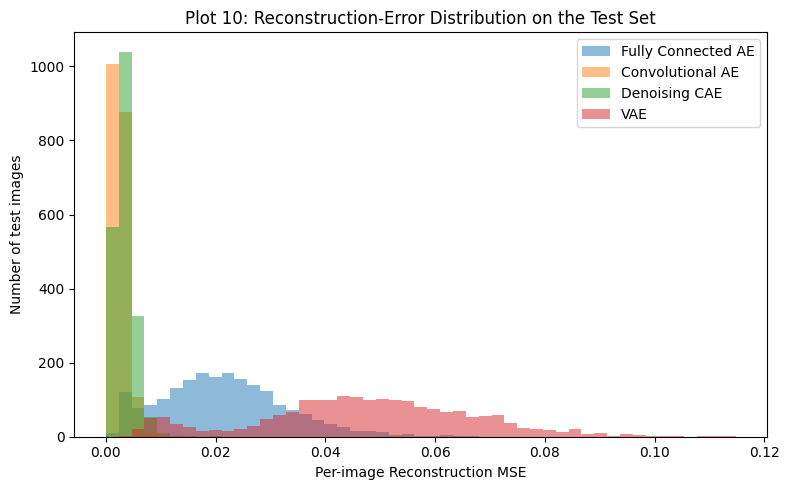

Mean / Std per model:
FC AE            mean=0.0215  std=0.0113
CNN AE           mean=0.0025  std=0.0013
Denoising CAE    mean=0.0034  std=0.0018
VAE              mean=0.0474  std=0.0194


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def per_image_mse(originals_img, recon_img):
    o = originals_img.reshape(len(originals_img), -1)
    r = recon_img.reshape(len(recon_img), -1)
    return np.mean(np.square(o - r), axis=1)

fc_errors = per_image_mse(x_test_img, fc_recon)
cae_errors = per_image_mse(x_test_img, cae_recon)
dae_errors = per_image_mse(x_test_img, dae_recon)
vae_errors = per_image_mse(x_test_img, vae_recon)

plt.figure(figsize=(8, 5))
bins = np.linspace(0, max(fc_errors.max(), cae_errors.max(), dae_errors.max(), vae_errors.max()), 50)

plt.hist(fc_errors, bins=bins, alpha=0.5, label="Fully Connected AE")
plt.hist(cae_errors, bins=bins, alpha=0.5, label="Convolutional AE")
plt.hist(dae_errors, bins=bins, alpha=0.5, label="Denoising CAE")
plt.hist(vae_errors, bins=bins, alpha=0.5, label="VAE")

plt.xlabel("Per-image Reconstruction MSE")
plt.ylabel("Number of test images")
plt.title("Plot 10: Reconstruction-Error Distribution on the Test Set")
plt.legend()
plt.tight_layout()
plt.savefig("plot10_error_distribution.png", dpi=150)
plt.show()

print("Mean / Std per model:")
for name, errs in [("FC AE", fc_errors), ("CNN AE", cae_errors),
                    ("Denoising CAE", dae_errors), ("VAE", vae_errors)]:
    print(f"{name:<16} mean={errs.mean():.4f}  std={errs.std():.4f}")

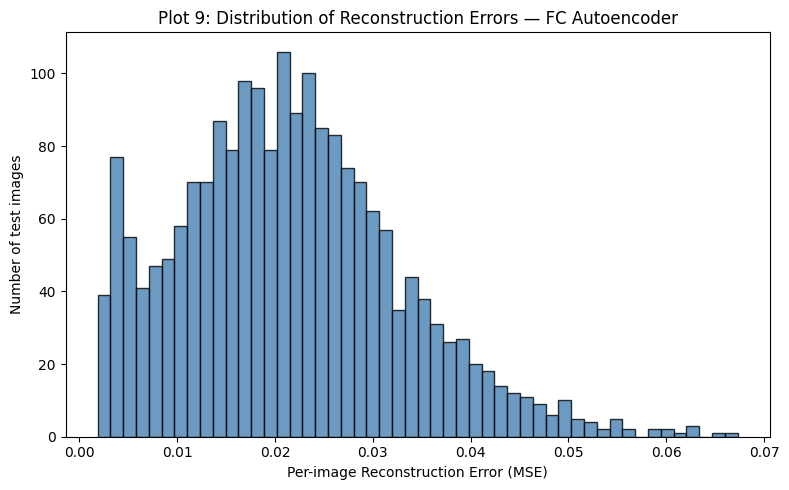

Min error:    0.0019
Max error:    0.0673
Mean error:   0.0215
Median error: 0.0208
Std error:    0.0113


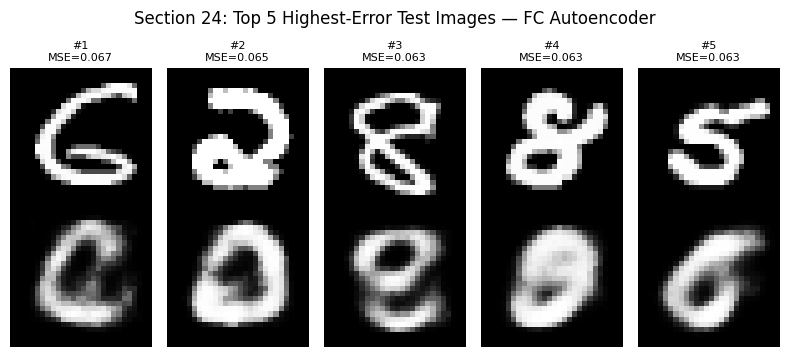


Top 5 highest-error samples:
  1. test index 513, MSE = 0.0673
  2. test index 1441, MSE = 0.0647
  3. test index 1771, MSE = 0.0631
  4. test index 1394, MSE = 0.0629
  5. test index 1033, MSE = 0.0627


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------
# Per-image reconstruction error: e_i = (1/D) * sum_j (x_ij - xhat_ij)^2
# -----------------------------------------------------------------
D = 784
errors = np.mean(np.square(x_test_flat - fc_recon.reshape(-1, 784)), axis=1)

# -----------------------------------------------------------------
# Plot 9: Distribution of Reconstruction Errors (FC Autoencoder)
# -----------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=50, color="steelblue", edgecolor="black", alpha=0.8)
plt.xlabel("Per-image Reconstruction Error (MSE)")
plt.ylabel("Number of test images")
plt.title("Plot 9: Distribution of Reconstruction Errors — FC Autoencoder")
plt.tight_layout()
plt.savefig("plot9_error_distribution_fc.png", dpi=150)
plt.show()

print(f"Min error:    {errors.min():.4f}")
print(f"Max error:    {errors.max():.4f}")
print(f"Mean error:   {errors.mean():.4f}")
print(f"Median error: {np.median(errors):.4f}")
print(f"Std error:    {errors.std():.4f}")

# -----------------------------------------------------------------
# Section 24: Top 5 highest-error images — Original vs Reconstruction
# -----------------------------------------------------------------
top5_idx = np.argsort(errors)[-5:][::-1]  # highest error first

fig, axes = plt.subplots(2, 5, figsize=(5 * 1.6, 3.6))
for col, idx in enumerate(top5_idx):
    axes[0, col].imshow(x_test_flat[idx].reshape(28, 28), cmap="gray")
    axes[0, col].set_title(f"#{col+1}\nMSE={errors[idx]:.3f}", fontsize=8)
    axes[0, col].axis("off")

    axes[1, col].imshow(fc_recon.reshape(-1, 28, 28)[idx], cmap="gray")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=9)
axes[1, 0].set_ylabel("Reconstruction", fontsize=9)
fig.suptitle("Section 24: Top 5 Highest-Error Test Images — FC Autoencoder")
plt.tight_layout()
plt.savefig("plot_top5_high_error.png", dpi=150)
plt.show()

print("\nTop 5 highest-error samples:")
for rank, idx in enumerate(top5_idx, 1):
    print(f"  {rank}. test index {idx}, MSE = {errors[idx]:.4f}")

Train shape: (10000, 784), Test shape: (2000, 784)

Training FC Autoencoder with latent dimension dz = 2
Epoch 1/20
79/79 - 5s - 70ms/step - loss: 0.3625 - val_loss: 0.2656
Epoch 2/20
79/79 - 0s - 4ms/step - loss: 0.2581 - val_loss: 0.2472
Epoch 3/20
79/79 - 0s - 4ms/step - loss: 0.2434 - val_loss: 0.2388
Epoch 4/20
79/79 - 0s - 4ms/step - loss: 0.2367 - val_loss: 0.2333
Epoch 5/20
79/79 - 0s - 4ms/step - loss: 0.2321 - val_loss: 0.2294
Epoch 6/20
79/79 - 0s - 4ms/step - loss: 0.2289 - val_loss: 0.2265
Epoch 7/20
79/79 - 1s - 9ms/step - loss: 0.2256 - val_loss: 0.2227
Epoch 8/20
79/79 - 1s - 6ms/step - loss: 0.2211 - val_loss: 0.2184
Epoch 9/20
79/79 - 0s - 6ms/step - loss: 0.2178 - val_loss: 0.2159
Epoch 10/20
79/79 - 0s - 6ms/step - loss: 0.2156 - val_loss: 0.2141
Epoch 11/20
79/79 - 0s - 4ms/step - loss: 0.2137 - val_loss: 0.2124
Epoch 12/20
79/79 - 0s - 4ms/step - loss: 0.2118 - val_loss: 0.2107
Epoch 13/20
79/79 - 0s - 4ms/step - loss: 0.2099 - val_loss: 0.2090
Epoch 14/20
79/79 -

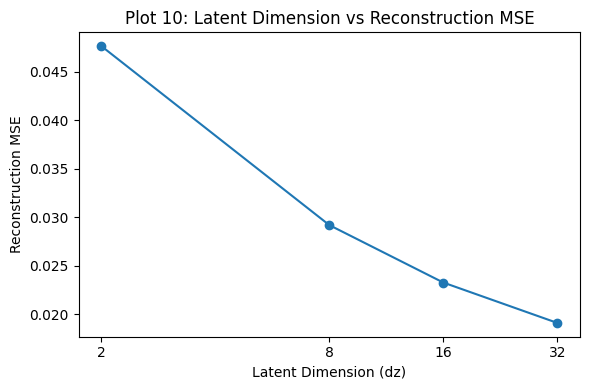

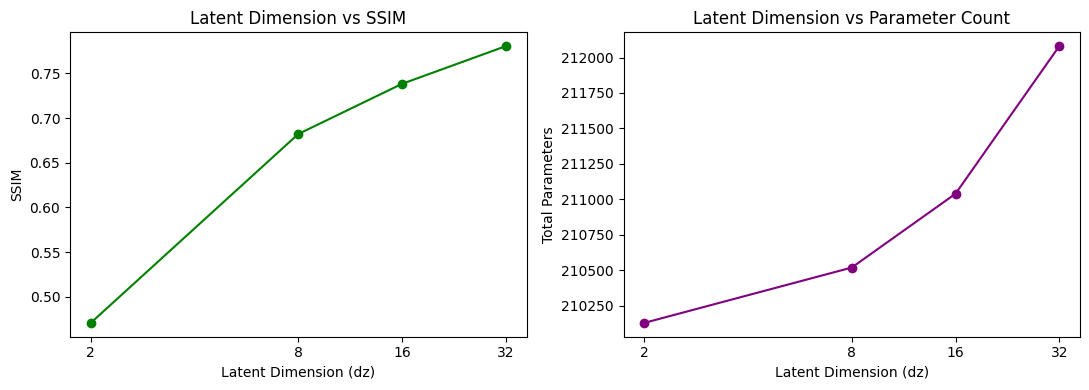

In [ ]:
"""
Section 27: Additional Latent-Dimension Study
================================================
Repeats the basic (Fully Connected) autoencoder at several latent
dimensions dz in {2, 8, 16, 32}, keeping everything else identical
(architecture shape, training config, data split), and reports how
reconstruction quality (MSE, SSIM) and parameter count change with dz.
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from skimage.metrics import structural_similarity as ssim

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

EPOCHS = 20
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
LATENT_DIMS = [2, 8, 16, 32]

# =====================================================================
# 1. Data (same lab subset used throughout)
# =====================================================================
(x_train_full, _), (x_test_full, _) = keras.datasets.mnist.load_data()

N_TRAIN, N_TEST = 10000, 2000
idx_train = np.random.choice(len(x_train_full), N_TRAIN, replace=False)
idx_test = np.random.choice(len(x_test_full), N_TEST, replace=False)

x_train = x_train_full[idx_train].astype("float32") / 255.0
x_test = x_test_full[idx_test].astype("float32") / 255.0

x_train_flat = x_train.reshape((-1, 784))
x_test_flat = x_test.reshape((-1, 784))

print(f"Train shape: {x_train_flat.shape}, Test shape: {x_test_flat.shape}")


def compute_mse_ssim(originals_flat, recon_flat):
    mse = np.mean(np.square(originals_flat - recon_flat))
    o_2d = originals_flat.reshape(-1, 28, 28)
    r_2d = recon_flat.reshape(-1, 28, 28)
    scores = [ssim(o_2d[i], r_2d[i], data_range=1.0) for i in range(len(o_2d))]
    return mse, np.mean(scores)


def build_fc_autoencoder(latent_dim):
    """Same 784-128-32-dz-32-128-784 shape as the basic FC autoencoder,
    just with the bottleneck width swapped out."""
    encoder_in = keras.Input(shape=(784,))
    x = layers.Dense(128, activation="relu")(encoder_in)
    x = layers.Dense(32, activation="relu")(x)
    latent = layers.Dense(latent_dim, activation="relu")(x)
    encoder = keras.Model(encoder_in, latent, name=f"encoder_dz{latent_dim}")

    decoder_in = keras.Input(shape=(latent_dim,))
    x = layers.Dense(32, activation="relu")(decoder_in)
    x = layers.Dense(128, activation="relu")(x)
    decoder_out = layers.Dense(784, activation="sigmoid")(x)
    decoder = keras.Model(decoder_in, decoder_out, name=f"decoder_dz{latent_dim}")

    ae_in = keras.Input(shape=(784,))
    autoencoder = keras.Model(ae_in, decoder(encoder(ae_in)), name=f"fc_ae_dz{latent_dim}")
    autoencoder.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE), loss="binary_crossentropy")
    return autoencoder


# =====================================================================
# 2. Train one FC autoencoder per latent dimension
# =====================================================================
results = []  # list of (dz, mse, ssim, params)

for dz in LATENT_DIMS:
    print(f"\n{'=' * 60}\nTraining FC Autoencoder with latent dimension dz = {dz}\n{'=' * 60}")
    ae = build_fc_autoencoder(dz)
    ae.fit(
        x_train_flat, x_train_flat,
        validation_data=(x_test_flat, x_test_flat),
        epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True, verbose=2,
    )
    recon = ae.predict(x_test_flat, verbose=0)
    mse, mean_ssim = compute_mse_ssim(x_test_flat, recon)
    params = ae.count_params()
    results.append((dz, mse, mean_ssim, params))
    print(f"dz={dz}: MSE={mse:.4f}, SSIM={mean_ssim:.4f}, Parameters={params:,}")


# =====================================================================
# 3. Report table
# =====================================================================
print("\n" + "=" * 60)
print("Table: Latent Dimension vs Reconstruction Quality")
print("=" * 60)
print(f"{'Latent Dimension':<18}{'MSE':>10}{'SSIM':>10}{'Parameters':>14}")
for dz, mse, mean_ssim, params in results:
    print(f"{dz:<18}{mse:>10.4f}{mean_ssim:>10.4f}{params:>14,}")


# =====================================================================
# Plot 10: Latent Dimension vs Reconstruction MSE
# =====================================================================
dzs = [r[0] for r in results]
mses = [r[1] for r in results]

plt.figure(figsize=(6, 4))
plt.plot(dzs, mses, marker="o")
plt.xscale("log", base=2)
plt.xticks(dzs, [str(d) for d in dzs])
plt.xlabel("Latent Dimension (dz)")
plt.ylabel("Reconstruction MSE")
plt.title("Plot 10: Latent Dimension vs Reconstruction MSE")
plt.tight_layout()
plt.savefig("plot10_latent_dim_vs_mse.png", dpi=150)
plt.show()

# For reference: SSIM and parameter count vs dz, on their own axes
# (kept separate from the MSE plot since the scales are incompatible)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ssims = [r[2] for r in results]
params_list = [r[3] for r in results]

axes[0].plot(dzs, ssims, marker="o", color="green")
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(dzs); axes[0].set_xticklabels([str(d) for d in dzs])
axes[0].set_xlabel("Latent Dimension (dz)"); axes[0].set_ylabel("SSIM")
axes[0].set_title("Latent Dimension vs SSIM")

axes[1].plot(dzs, params_list, marker="o", color="purple")
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(dzs); axes[1].set_xticklabels([str(d) for d in dzs])
axes[1].set_xlabel("Latent Dimension (dz)"); axes[1].set_ylabel("Total Parameters")
axes[1].set_title("Latent Dimension vs Parameter Count")

plt.tight_layout()
plt.savefig("plot10b_latent_dim_ssim_params.png", dpi=150)
plt.show()

# -----------------------------------------------------------------
# Required explanation: compression vs reconstruction quality trade-off
# -----------------------------------------------------------------
# - As dz increases (2 -> 8 -> 16 -> 32), MSE should DECREASE and SSIM
#   should INCREASE: a wider bottleneck can retain more information about
#   each image, so reconstructions become more accurate.
# - Parameter count grows only slightly with dz here (the bottleneck layer
#   itself is small relative to the 128/32-unit hidden layers), so the
#   accuracy gain is "cheap" in terms of model size across this range.
# - Diminishing returns: check whether the MSE improvement from dz=2->8
#   is much larger than the improvement from dz=16->32 — if so, this shows
#   the model captures most of the useful digit variation within a
#   relatively small number of latent dimensions, and additional dimensions
#   yield progressively smaller quality gains (a classic compression /
#   fidelity trade-off curve with diminishing returns).
# - At the smallest dz (2), the bottleneck is so narrow that the model
#   is forced into heavy, lossy compression -- expect the highest MSE /
#   lowest SSIM here, similar in spirit to why the VAE (also dz=2)
#   struggled with sharp reconstruction earlier in this lab.